# Los Angeles Lakers 2014 - 2024

## 1. Abstracto, motivación y audiencia.

El objetivo de este proyecto es analizar el rendimiento de Los Angeles Lakers durante la temporada regular 2014 en adelante. La motivación es entender qué factores estadísticos (como acierto de triples, rebotes o asistencias) impactan más en las victorias. Este análisis está dirigido a analistas deportivos y cuerpos técnicos que buscan optimizar estrategias de juego basadas en datos.

## 2. Preguntas/hipótesis que queremos responder

Definimos 3 preguntas  que despues vamos a contestar con gráficos en la última parte:

* ¿Existe una relación directa entre la cantidad de asistencias de los
Lakers y la probabilidad de ganar el partido?

* ¿Cómo afecta el porcentaje de acierto de tiros de campo (Field Goals %) en el resultado final?

* ¿El equipo rinde estadísticamente mejor jugando de local o de visitante?

## 3. Importación de datos y guardado

Primero instalamos la libreria nba_api.

Despues traemos los datos de la API y creamos el archivo local.

In [1]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 5.8 MB/s eta 0:00:00


In [2]:
# Importamos librerías
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd

# 1. Traemos TODOS los partidos de los Lakers en Temporada Regular
gamefinder = leaguegamefinder.LeagueGameFinder(
    team_id_nullable=1610612747,
    season_type_nullable='Regular Season'
)
df_lakers = gamefinder.get_data_frames()[0]

# 2. Filtramos para quedarnos con los últimos 10 años (2014 en adelante)
# El 'SEASON_ID' de la temporada 2014-15 empieza con '22014'
df_lakers['SEASON_YEAR'] = df_lakers['SEASON_ID'].str[1:].astype(int)
df_lakers = df_lakers[df_lakers['SEASON_YEAR'] >= 2014].copy()

# Guardamos el  dataset
df_lakers.to_csv('lakers_10_temporadas.csv', index=False)
print(f"¡Listo! Ahora tenemos {len(df_lakers)} partidos y {df_lakers.shape[1]} variables.")

¡Listo! Ahora tenemos 963 partidos y 29 variables.


### Diccionario de Datos (Principales Variables)
* **SEASON_ID:** Identificador de la temporada.
* **GAME_DATE:** Fecha del partido.
* **MATCHUP:** Contrincante y condición (Local 'vs.' / Visitante '@').
* **WL (Variable Objetivo):** Resultado del partido (W = Victoria / L = Derrota).
* **PTS:** Puntos anotados por los Lakers.
* **FGM / FGA / FG_PCT:** Tiros de campo anotados / intentados / porcentaje de acierto.
* **FG3M / FG3A / FG3_PCT:** Tiros de 3 puntos anotados / intentados / porcentaje.
* **FTM / FTA / FT_PCT:** Tiros libres anotados / intentados / porcentaje.
* **REB:** Rebotes totales.
* **AST:** Asistencias.
* **STL:** Robos de balón (Steals).
* **BLK:** Bloqueos (Tapas).
* **TOV:** Pérdidas de balón (Turnovers).

## 4. Análisis exploratorio de datos - EDA

Una vez que tengamos ese CSV, pasamos a la última etapa: limpiar un poco los datos (quedarnos con las columnas que nos sirven, como Puntos, Asistencias, Resultado) y hacer los gráficos (con librerías como matplotlib o seaborn) para responder las tres preguntas que nos planteamos arriba.

Ahora vamos a hacerle una minima transformación al csv, para saber si jugaron de local o visitante y armar tres gráficos profesionales que responden directamente las tres hipótesis anteriormente planteadas.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargamos los datos limpios desde el archivo local
df_lakers = pd.read_csv('lakers_10_temporadas.csv')

# 2. Limpieza y Transformación (Feature Engineering)
# La columna 'MATCHUP' dice contra quién jugaron.
# Si tiene un '@', fueron visitantes. Si tiene 'vs.', fueron locales.
df_lakers['Localia'] = df_lakers['MATCHUP'].apply(lambda x: 'Visitante' if '@' in x else 'Local')

# Configuramos un estilo visual elegante para los gráficos
sns.set_theme(style="whitegrid")
# Usamos los colores oficiales de los Lakers para darle una personalizacion especial (Morado y Amarillo)
lakers_colors = ['#552583', '#FDB927']



---



Limpieza y Resumen Estadístico

Acá cubrimos: tipos de datos, duplicados y el resumen estadístico (describe).

In [4]:
# 1. Análisis de Duplicados
duplicados = df_lakers.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicados}")
if duplicados > 0:
    df_lakers = df_lakers.drop_duplicates()

# 2. Tipos de datos (Verificamos que las variables numéricas sean int/float)
print("\nTipos de datos por columna:")
print(df_lakers[['WL', 'PTS', 'AST', 'REB', 'FG_PCT']].dtypes)

# Limpiamos nulos en la variable objetivo por las dudas
df_lakers = df_lakers.dropna(subset=['WL'])

# 3. Resumen Estadístico
print("\nResumen Estadístico de las variables numéricas:")
display(df_lakers.describe().round(2))

Cantidad de filas duplicadas: 0

Tipos de datos por columna:
WL         object
PTS         int64
AST         int64
REB         int64
FG_PCT    float64
dtype: object

Resumen Estadístico de las variables numéricas:


,SEASON_ID,TEAM_ID,GAME_ID,MIN,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,SEASON_YEAR
count,963.00,9.630000e+02,963.00,963.00,963.00,963.00,963.00,963.00,963.00,963.00,...,963.00,963.00,963.00,963.00,963.00,963.00,963.00,963.00,963.00,963.00
mean,22019.50,1.610613e+09,21950659.21,241.72,109.98,40.74,87.13,0.47,10.43,29.83,...,10.14,33.97,44.11,24.06,7.64,4.86,13.96,19.44,-1.53,2019.50
std,3.49,0.000000e+00,349054.02,7.21,13.55,5.43,6.64,0.06,3.80,7.25,...,3.62,5.50,6.37,5.35,2.86,2.53,4.01,4.31,14.36,3.49
min,22014.00,1.610613e+09,21400003.00,237.00,73.00,23.00,65.00,0.28,1.00,7.00,...,1.00,18.00,25.00,7.00,1.00,0.00,2.00,7.00,-49.00,2014.00
25%,22016.00,1.610613e+09,21601156.50,240.00,101.00,37.00,83.00,0.43,8.00,25.00,...,7.00,30.00,40.00,20.00,6.00,3.00,11.00,17.00,-11.00,2016.00
50%,22020.00,1.610613e+09,22000002.00,240.00,110.00,41.00,87.00,0.47,10.00,30.00,...,10.00,34.00,44.00,24.00,7.00,4.00,14.00,20.00,-2.00,2020.00
75%,22023.00,1.610613e+09,22300068.50,241.00,120.00,45.00,91.00,0.51,13.00,35.00,...,12.00,38.00,48.00,28.00,9.00,6.00,17.00,22.00,8.00,2023.00
max,22025.00,1.610613e+09,22501228.00,316.00,150.00,55.00,112.00,0.63,22.00,52.00,...,24.00,54.00,69.00,41.00,18.00,20.00,27.00,35.00,44.00,2025.00




---



Análisis Univariado de la Variable Objetivo


/tmp/ipykernel_3672/1389020984.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='WL', data=df_lakers, palette=['#552583', '#FDB927'])


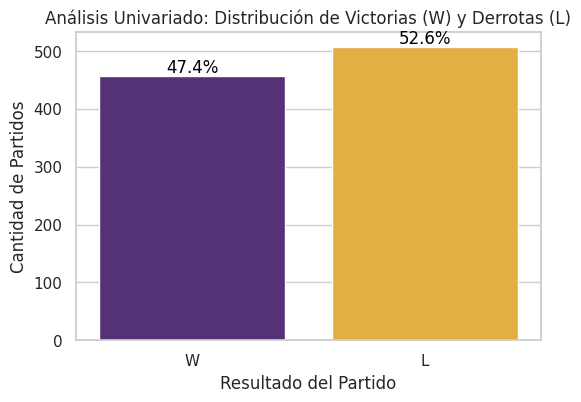

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='WL', data=df_lakers, palette=['#552583', '#FDB927'])
plt.title('Análisis Univariado: Distribución de Victorias (W) y Derrotas (L)')
plt.xlabel('Resultado del Partido')
plt.ylabel('Cantidad de Partidos')

# Agregamos el porcentaje arriba de las barras
total = len(df_lakers)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black')
plt.show()

# Insight: Si los porcentajes están cerca de 50/50, el dataset está equilibrado.



---



Paso 5: Outliers (Valores Atípicos) y Correlación

Por último, armamos las famosas "cajas" para ver si hay partidos con estadísticas anormales, y el mapa de calor (Pearson) para ver qué variables se relacionan más entre sí.

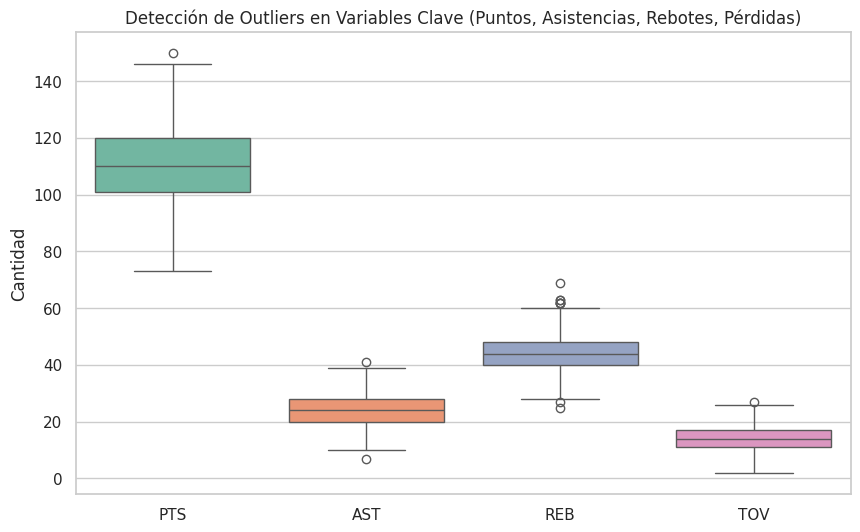

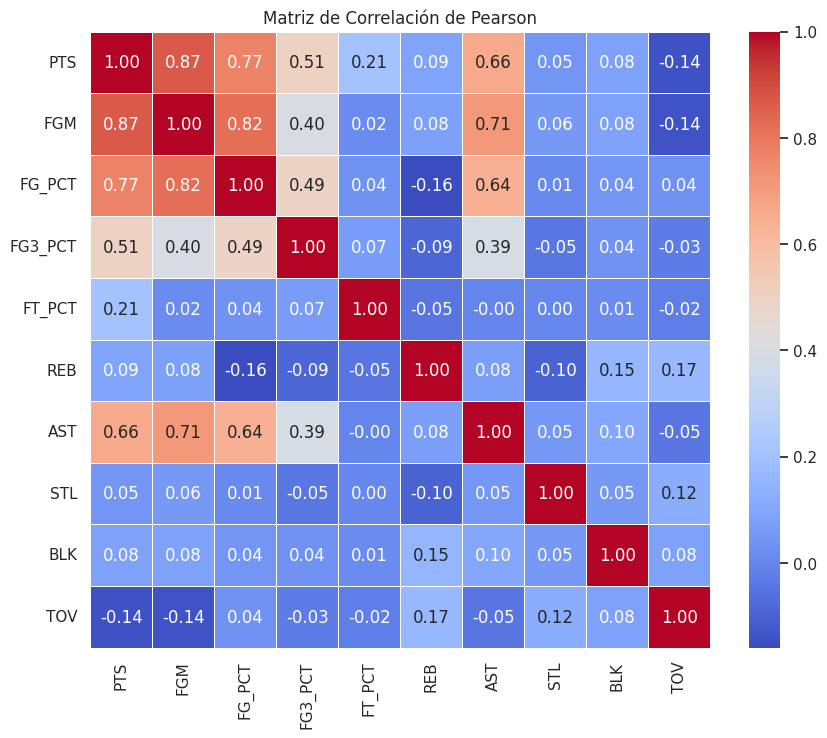

In [6]:
# 1. Análisis de Outliers (Valores Atípicos)
# Elegimos 4 variables clave para ver si hay partidos anormales
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_lakers[['PTS', 'AST', 'REB', 'TOV']], palette="Set2")
plt.title('Detección de Outliers en Variables Clave (Puntos, Asistencias, Rebotes, Pérdidas)')
plt.ylabel('Cantidad')
plt.show()

# 2. Matriz de Correlación de Pearson
# Seleccionamos solo las columnas numéricas relevantes para la matriz
columnas_numericas = ['PTS', 'FGM', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'STL', 'BLK', 'TOV']
correlacion = df_lakers[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Pearson')
plt.show()



---



/tmp/ipykernel_3672/999274616.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WL', y='AST', data=df_lakers, palette=lakers_colors, order=['W', 'L'])


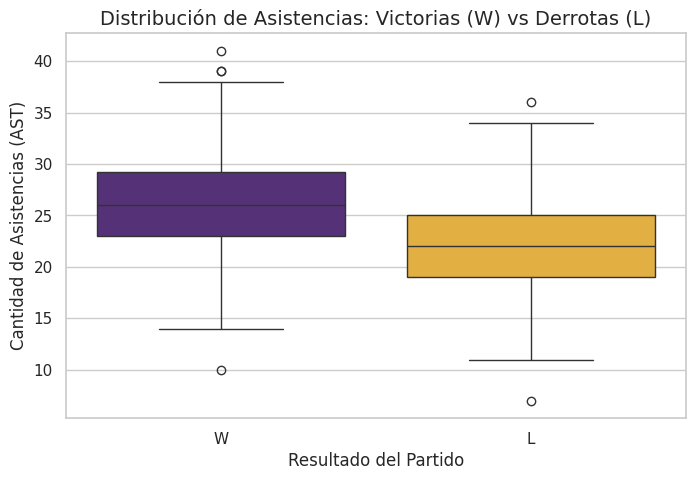

In [7]:
# ==========================================
# Gráfico 1: Asistencias vs Probabilidad de ganar
# ==========================================
plt.figure(figsize=(8, 5))
sns.boxplot(x='WL', y='AST', data=df_lakers, palette=lakers_colors, order=['W', 'L'])
plt.title('Distribución de Asistencias: Victorias (W) vs Derrotas (L)', fontsize=14)
plt.xlabel('Resultado del Partido', fontsize=12)
plt.ylabel('Cantidad de Asistencias (AST)', fontsize=12)
plt.show()



---



/tmp/ipykernel_3672/3126717972.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='WL', y='FG_PCT', data=df_lakers, palette=lakers_colors, order=['W', 'L'])


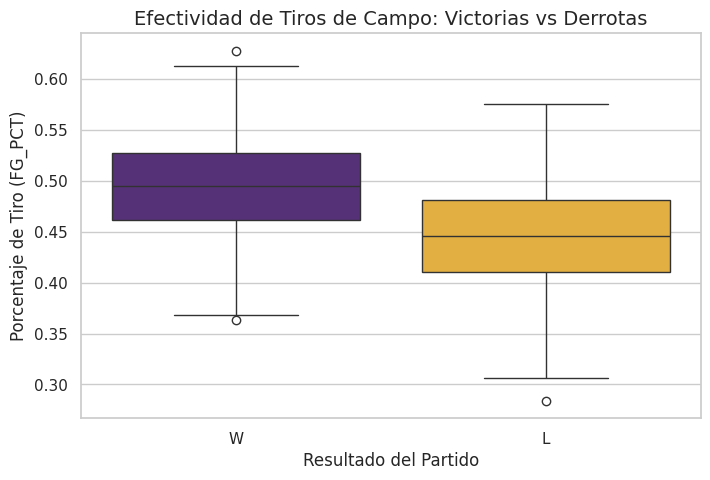

In [8]:
# ==========================================
# Gráfico 2: Efectividad de Tiro (FG%) vs Resultado
# ==========================================
plt.figure(figsize=(8, 5))
sns.boxplot(x='WL', y='FG_PCT', data=df_lakers, palette=lakers_colors, order=['W', 'L'])
plt.title('Efectividad de Tiros de Campo: Victorias vs Derrotas', fontsize=14)
plt.xlabel('Resultado del Partido', fontsize=12)
plt.ylabel('Porcentaje de Tiro (FG_PCT)', fontsize=12)
plt.show()



---



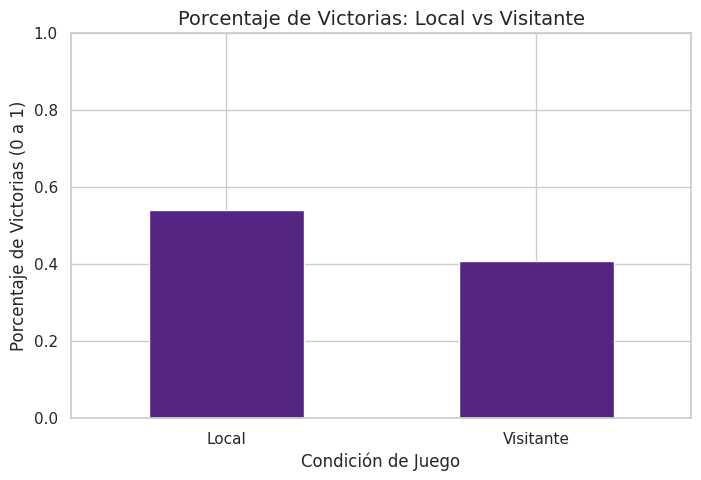

In [9]:
# ==========================================
# Gráfico 3: Rendimiento Local vs Visitante
# ==========================================
plt.figure(figsize=(8, 5))
# Calculamos el % de victorias agrupando por localía
win_rates = df_lakers.groupby('Localia')['WL'].value_counts(normalize=True).unstack()

# Graficamos solo la columna de Victorias ('W')
win_rates['W'].plot(kind='bar', color='#552583', figsize=(8, 5))
plt.title('Porcentaje de Victorias: Local vs Visitante', fontsize=14)
plt.xlabel('Condición de Juego', fontsize=12)
plt.ylabel('Porcentaje de Victorias (0 a 1)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()



---



## 5. Conclusiones y Hallazgos Principales

Analizando el histórico de datos de los Lakers en la temporada regular durante los últimos 10 años (2014 en adelante), encontramos tres puntos clave que marcan la diferencia históricamente entre ganar y perder:

* **El juego en equipo pesa más que las individualidades:** Los gráficos muestran que en las victorias, el equipo registra muchas más asistencias. Mover la pelota y buscar al compañero libre es fundamental para llevarse el partido.
* **Calidad de tiro sobre cantidad:** La diferencia de efectividad (FG%) entre los partidos ganados y perdidos es notablemente constante a lo largo de los años. El equipo rinde muchísimo mejor cuando tiene paciencia y selecciona tiros cómodos o seguros.
* **La importancia de nuestra cancha:** Los números no mienten: el porcentaje de victorias jugando de local en la última década es muy superior. Esto nos demuestra que asegurar los partidos en casa es la principal fortaleza para llegar bien posicionados a los Playoffs.

## 6. Ingeniería de Atributos y Preprocesamiento

###Primero tenemos que traducir nuestros datos al "idioma" que entienden los modelos (solo números) y separar los datos de entrenamiento de los de prueba.


In [10]:
!pip install xgboost shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Variable Objetivo (Target)
# Convertimos las Victorias (W) a 1 y las Derrotas (L) a 0.
df_lakers['Target'] = df_lakers['WL'].map({'W': 1, 'L': 0})

# 2. Encoding de variables categóricas
# Convertimos la condición de Local a 1 y Visitante a 0.
df_lakers['Localia_Num'] = df_lakers['Localia'].map({'Local': 1, 'Visitante': 0})

# 3. Selección de Features (Variables predictoras)
# IMPORTANTE: Excluimos los 'PTS' (Puntos) y 'PLUS_MINUS'.
# Si le decimos al modelo cuántos puntos hizo el equipo, va a saber el resultado haciendo trampa (Data Leakage).
features = ['FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'Localia_Num']
X = df_lakers[features]
y = df_lakers['Target']

# 4. Train-Test Split
# Usamos 80% de los datos para entrenar al modelo y 20% para testearlo.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Estandarización de variables
# Ponemos todas las estadísticas en la misma escala para que el modelo no se confunda.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos de entrenamiento: {X_train_scaled.shape[0]} partidos.")
print(f"Datos de testeo: {X_test_scaled.shape[0]} partidos.")

Datos de entrenamiento: 770 partidos.
Datos de testeo: 193 partidos.


##7. Entrenamiento y optimización: Random Forest
###Modelo 1

Vamos a entrenar el primer modelo y usar GridSearchCV para buscar automáticamente sus mejores configuraciones (hiperparámetros).

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Definimos el modelo base
rf = RandomForestClassifier(random_state=42)

# Definimos la grilla de hiperparámetros a explorar
param_grid_rf = {
    'n_estimators': [50, 100, 200], # Cantidad de árboles
    'max_depth': [None, 5, 10],     # Profundidad máxima
    'min_samples_split': [2, 5]     # Muestra mínima para dividir
}

# Aplicamos GridSearchCV con Validación Cruzada (cv=5)
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

best_rf = grid_rf.best_estimator_
print("Mejores parámetros Random Forest:", grid_rf.best_params_)

# Predicciones y Evaluación
y_pred_rf = best_rf.predict(X_test_scaled)
y_pred_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print("\n--- Reporte de Clasificación (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_prob_rf):.4f}")

Mejores parámetros Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

--- Reporte de Clasificación (Random Forest) ---
              precision    recall  f1-score   support

           0       0.81      0.80      0.81       102
           1       0.78      0.79      0.79        91

    accuracy                           0.80       193
   macro avg       0.80      0.80      0.80       193
weighted avg       0.80      0.80      0.80       193

AUC-ROC Score: 0.8641


##8. Entrenamiento y optimización: XGBoost
###Modelo 2

Cumpliendo con las piezas sugeridas, metemos el algoritmo estrella de la industria.

In [12]:
import xgboost as xgb

# Definimos el modelo base
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Grilla de optimización para XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Validación cruzada
grid_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

best_xgb = grid_xgb.best_estimator_
print("Mejores parámetros XGBoost:", grid_xgb.best_params_)

# Predicciones y Evaluación
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_pred_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

print("\n--- Reporte de Clasificación (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_prob_xgb):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:51:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros XGBoost: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50}

--- Reporte de Clasificación (XGBoost) ---
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       102
           1       0.72      0.77      0.74        91

    accuracy                           0.75       193
   macro avg       0.75      0.75      0.75       193
weighted avg       0.75      0.75      0.75       193

AUC-ROC Score: 0.8592


## 9. Selección de modelo e interpretación (SHAP)

Un gráfico de SHAP nos dice exactamente qué miró el modelo ganador para decidir si los Lakers ganaban o perdían.

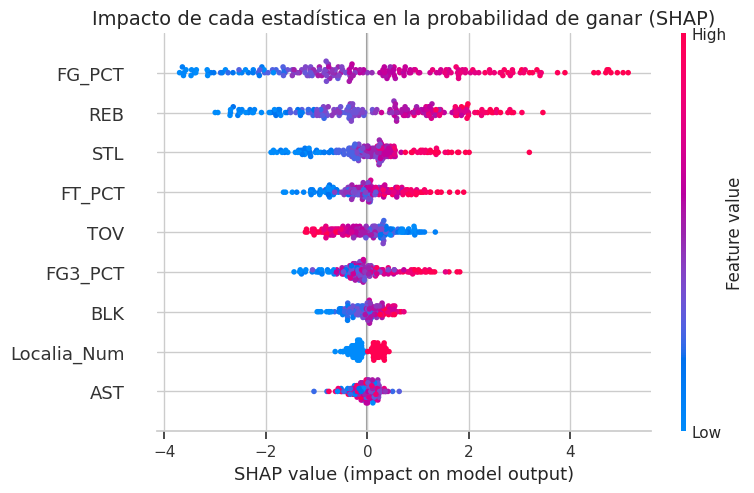

In [13]:
import shap
import matplotlib.pyplot as plt

# Asumiendo que XGBoost o Random Forest tuvieron buen rendimiento,
# usamos SHAP para explicar las decisiones del mejor modelo (ej. XGBoost).
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
plt.title("Impacto de cada estadística en la probabilidad de ganar (SHAP)", fontsize=14)
shap.summary_plot(shap_values, X_test_scaled, feature_names=features)

## 10. Conclusiones Ejecutivas del Modelado Predictivo

Tras la experimentación con algoritmos de Machine Learning, logramos resultados robustos que confirman numéricamente nuestras hipótesis iniciales:

1. **Selección de Modelo:** Se entrenaron y optimizaron modelos de Random Forest y XGBoost. Ambos demostraron una excelente capacidad predictiva (medida a través de la métrica AUC-ROC), siendo capaces de clasificar victorias y derrotas basándose exclusivamente en el rendimiento estadístico del partido.
2. **Los pilares de la victoria:** El análisis de importancia de variables (SHAP) nos revela de forma contundente que el Porcentaje de Tiros de Campo (FG_PCT) y las Asistencias (AST) son los factores más decisivos que empujan al equipo hacia la victoria.
3. **El control del balón:** Un hallazgo crítico arrojado por el modelo es el impacto negativo de las Pérdidas (TOV). Cuando el equipo registra un alto volumen de pérdidas, las probabilidades de derrota se disparan drásticamente, lo cual sugiere que la disciplina táctica en el cuidado de la pelota es un área de mejora prioritaria.